In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from textblob import TextBlob

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

lyrics = pd.read_csv('../data/taylor_swift_lyrics_full.csv')
song_attributes = pd.read_csv('../data/Taylor Swift Spotify Data 11-24-2024.csv')

song_attributes.head()

,artist_name,artist_id,album_id,album_type,album_release_date,album_release_year,album_release_date_precision,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_id,analysis_url,time_signature,disc_number,duration_ms,explicit,track_href,track_name,preview_url,track_number,type,track_uri,is_local,external_urls.spotify,album_name,restrictions.reason,key_name,mode_name,key_mode
0,Taylor Swift,06HL4z0CvFAxyc27GXpf02,5eyZZoQEFQWRHkV2xgAeBw,album,10/24/06,2006,day,0.580,0.491,0,-6.462,1,0.0251,0.575,0.0,0.1210,0.425,76.009,2Fn01AIMyHbha2ceNQeOqw,https://api.spotify.com/v1/audio-analysis/2Fn0...,4,1,232106,False,https://api.spotify.com/v1/tracks/2Fn01AIMyHbh...,Tim McGraw,NaN,1,track,spotify:track:2Fn01AIMyHbha2ceNQeOqw,False,https://open.spotify.com/track/2Fn01AIMyHbha2c...,Taylor Swift,NaN,C,major,C major
1,Taylor Swift,06HL4z0CvFAxyc27GXpf02,5eyZZoQEFQWRHkV2xgAeBw,album,10/24/06,2006,day,0.658,0.877,7,-2.098,1,0.0323,0.173,0.0,0.0962,0.821,105.586,4BYejINgfZF0qKDMEH2cim,https://api.spotify.com/v1/audio-analysis/4BYe...,4,1,173066,False,https://api.spotify.com/v1/tracks/4BYejINgfZF0...,Picture To Burn,NaN,2,track,spotify:track:4BYejINgfZF0qKDMEH2cim,False,https://open.spotify.com/track/4BYejINgfZF0qKD...,Taylor Swift,NaN,G,major,G major
2,Taylor Swift,06HL4z0CvFAxyc27GXpf02,5eyZZoQEFQWRHkV2xgAeBw,album,10/24/06,2006,day,0.621,0.417,10,-6.941,1,0.0231,0.288,0.0,0.1190,0.289,99.953,2TF4UtYreqNbQ6Z9AccldU,https://api.spotify.com/v1/audio-analysis/2TF4...,4,1,203040,False,https://api.spotify.com/v1/tracks/2TF4UtYreqNb...,Teardrops On My Guitar - Radio Single Remix,NaN,3,track,spotify:track:2TF4UtYreqNbQ6Z9AccldU,False,https://open.spotify.com/track/2TF4UtYreqNbQ6Z...,Taylor Swift,NaN,A#,major,A# major
3,Taylor Swift,06HL4z0CvFAxyc27GXpf02,5eyZZoQEFQWRHkV2xgAeBw,album,10/24/06,2006,day,0.576,0.777,9,-2.881,1,0.0324,0.051,0.0,0.3200,0.428,115.028,1oR4MUBpyNrAViC8wPNpfm,https://api.spotify.com/v1/audio-analysis/1oR4...,4,1,199200,False,https://api.spotify.com/v1/tracks/1oR4MUBpyNrA...,A Place in this World,NaN,4,track,spotify:track:1oR4MUBpyNrAViC8wPNpfm,False,https://open.spotify.com/track/1oR4MUBpyNrAViC...,Taylor Swift,NaN,A,major,A major
4,Taylor Swift,06HL4z0CvFAxyc27GXpf02,5eyZZoQEFQWRHkV2xgAeBw,album,10/24/06,2006,day,0.418,0.482,5,-5.769,1,0.0266,0.217,0.0,0.1230,0.261,175.558,569sXXQ7t0jSdqHooi2yqs,https://api.spotify.com/v1/audio-analysis/569s...,4,1,239013,False,https://api.spotify.com/v1/tracks/569sXXQ7t0jS...,Cold As You,NaN,5,track,spotify:track:569sXXQ7t0jSdqHooi2yqs,False,https://open.spotify.com/track/569sXXQ7t0jSdqH...,Taylor Swift,NaN,F,major,F major


In [2]:
lyrics.head()

In [4]:
def cleantrack(x):
    if " (" in x:
        return x[0:x.index(" (")]
    return x

In [5]:
song_attributes["track_name_formatted"]= song_attributes["track_name"].apply(cleantrack)

In [6]:
columns_from_song_att = ["track_name_formatted","album_name","danceability","energy","loudness","liveness","valence","tempo",]

In [7]:
merged_df = pd.merge(lyrics, song_attributes[columns_from_song_att], left_on=['track_title','album'] ,right_on=['track_name_formatted','album_name'], how='inner')

In [8]:
merged_df.head()

In [10]:
merged_df.to_csv('ts_merged_output.csv', index=False)

In [11]:
# ===== SETUP =====
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load your actual CSV
df = pd.read_csv('ts_merged_output.csv')

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

# ===== SENTIMENT ANALYSIS =====
print("\n=== CALCULATING SENTIMENT SCORES ===")

# Apply sentiment analysis to each lyric line using TextBlob
# Polarity ranges from -1 (negative) to 1 (positive)
df['sentiment_score'] = df['lyric'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

print(f"Sentiment score range: {df['sentiment_score'].min():.3f} to {df['sentiment_score'].max():.3f}")
print(f"Mean sentiment: {df['sentiment_score'].mean():.3f}")

# ===== AGGREGATE TO SONG LEVEL =====
# Since each row is a lyric line, we need to aggregate by song
song_level = df.groupby('track_name_formatted').agg({
    'sentiment_score': 'mean',  # Average sentiment across all lyrics
    'danceability': 'first',     # These are constant per song
    'energy': 'first',
    'loudness': 'first',
    'liveness': 'first',
    'valence': 'first',
    'tempo': 'first',
    'album_name': 'first',
    'year': 'first'
}).reset_index()

print(f"\n=== SONG-LEVEL AGGREGATION ===")
print(f"Total unique songs: {len(song_level)}")
print(f"\nSong-level data:")
print(song_level.head(10))

# ===== 1. BASIC STATISTICS =====
print("\n=== DESCRIPTIVE STATISTICS ===")
print(song_level[['sentiment_score', 'danceability', 'energy', 'loudness', 
                   'liveness', 'valence', 'tempo']].describe())



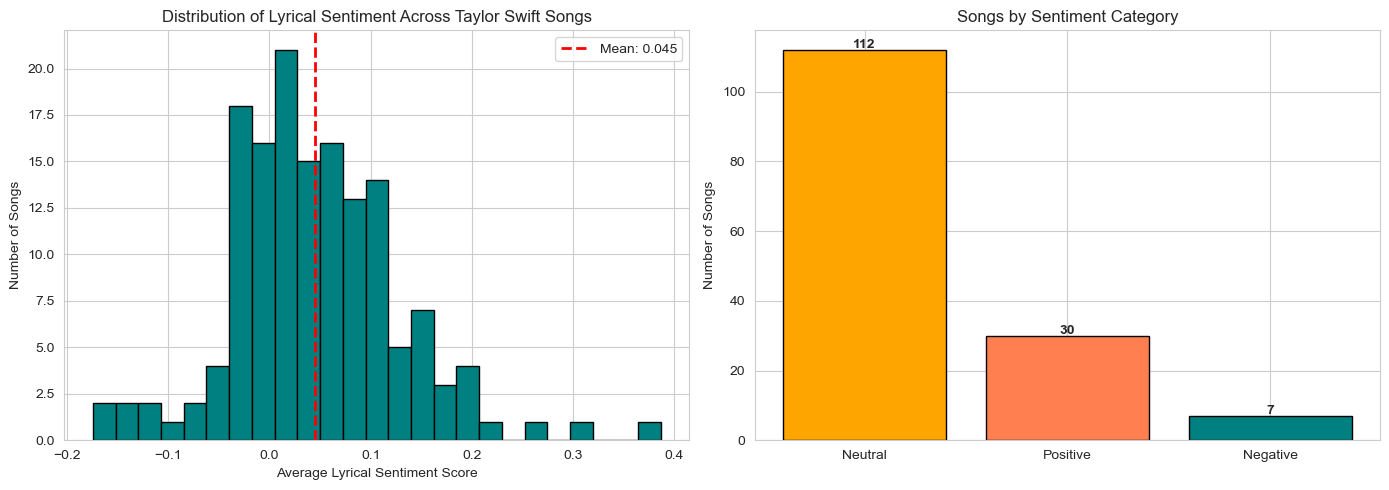

In [31]:
# ===== 2. SENTIMENT DISTRIBUTION =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(song_level['sentiment_score'], bins=25, color='teal', edgecolor='black')
axes[0].set_xlabel('Average Lyrical Sentiment Score')
axes[0].set_ylabel('Number of Songs')
axes[0].set_title('Distribution of Lyrical Sentiment Across Taylor Swift Songs')
axes[0].axvline(song_level['sentiment_score'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {song_level["sentiment_score"].mean():.3f}')
axes[0].legend()

# Categorize sentiment
song_level['sentiment_category'] = pd.cut(song_level['sentiment_score'], 
                                          bins=[-1, -0.1, 0.1, 1], 
                                          labels=['Negative', 'Neutral', 'Positive'])
sentiment_counts = song_level['sentiment_category'].value_counts()
colors = ['orange', 'coral', 'teal']
axes[1].bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='black')
axes[1].set_ylabel('Number of Songs')
axes[1].set_title('Songs by Sentiment Category')
for i, v in enumerate(sentiment_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('01_sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


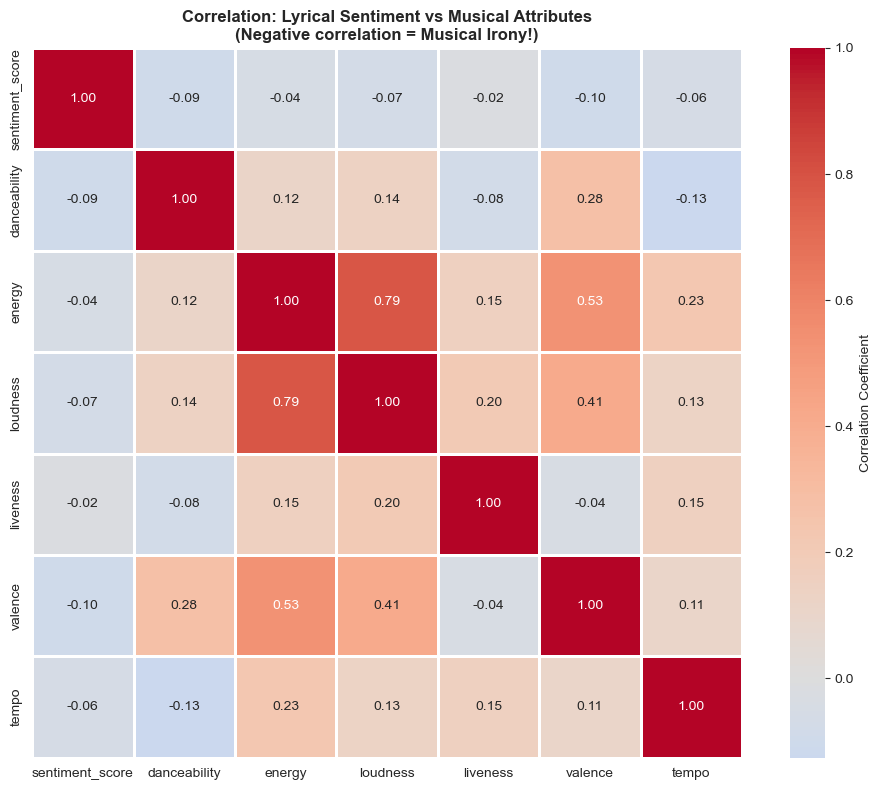

In [13]:
# ===== 3. CORRELATION MATRIX (KEY FOR IRONY DETECTION) =====
audio_features = ['danceability', 'energy', 'loudness', 'liveness', 'valence', 'tempo']
corr_cols = ['sentiment_score'] + audio_features

correlation_matrix = song_level[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation: Lyrical Sentiment vs Musical Attributes\n(Negative correlation = Musical Irony!)', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()



In [14]:
# ===== 4. IRONY SCORE CALCULATION =====
# Irony = Upbeat music + Sad lyrics (or vice versa)
# Calculate "musical positivity" from upbeat attributes
song_level['valence_energy_avg'] = (song_level['valence'] + song_level['energy']) / 2

# Irony score: How much does lyrical sentiment NOT match musical positivity?
song_level['irony_score'] = song_level['valence_energy_avg'] - song_level['sentiment_score']
# Positive irony_score = happy music, sad lyrics (IRONIC!)
# Negative irony_score = sad music, happy lyrics (also ironic but opposite direction)

print("\n=== IRONY ANALYSIS ===")
print(f"Mean Irony Score: {song_level['irony_score'].mean():.3f}")
print(f"Std Dev: {song_level['irony_score'].std():.3f}")
print(f"Min: {song_level['irony_score'].min():.3f}")
print(f"Max: {song_level['irony_score'].max():.3f}")

# Categorize by irony level
song_level['irony_level'] = pd.cut(song_level['irony_score'], 
                                    bins=[-np.inf, -0.2, 0.2, np.inf],
                                    labels=['Misaligned: Sad Music, Happy Lyrics', 
                                           'Aligned: Music Matches Lyrics',
                                           'IRONIC: Happy Music, Sad Lyrics'])

irony_dist = song_level['irony_level'].value_counts()
print("\nSongs by Irony Category:")
print(irony_dist)




=== IRONY ANALYSIS ===
Mean Irony Score: 0.439
Std Dev: 0.190
Min: -0.046
Max: 0.963

Songs by Irony Category:
irony_level
IRONIC: Happy Music, Sad Lyrics        137
Aligned: Music Matches Lyrics           12
Misaligned: Sad Music, Happy Lyrics      0
Name: count, dtype: int64


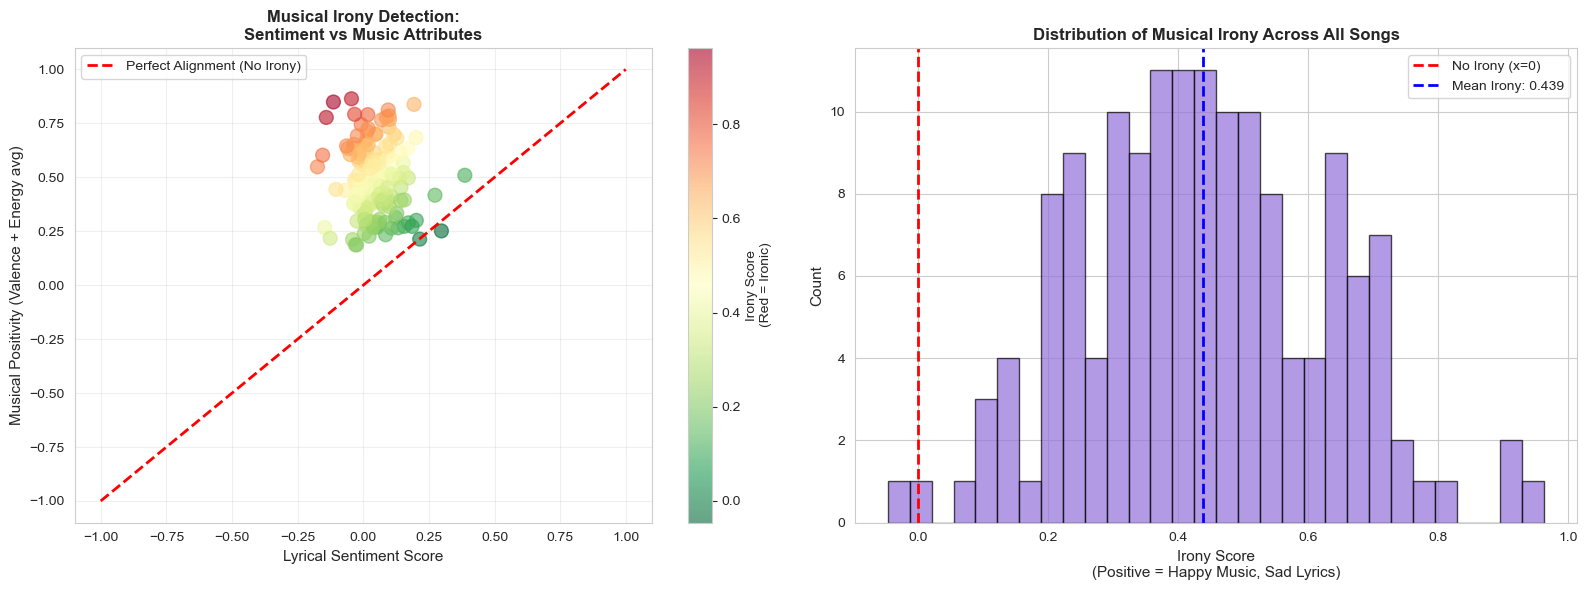

In [16]:
# ===== 5. VISUALIZE IRONY =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Sentiment vs Musical Positivity
scatter = axes[0].scatter(song_level['sentiment_score'], song_level['valence_energy_avg'], 
                         alpha=0.6, s=100, c=song_level['irony_score'], cmap='RdYlGn_r')
axes[0].plot([-1, 1], [-1, 1], 'r--', label='Perfect Alignment (No Irony)', linewidth=2)
axes[0].set_xlabel('Lyrical Sentiment Score', fontsize=11)
axes[0].set_ylabel('Musical Positivity (Valence + Energy avg)', fontsize=11)
axes[0].set_title('Musical Irony Detection:\nSentiment vs Music Attributes', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Irony Score\n(Red = Ironic)', fontsize=10)

# Irony score distribution
axes[1].hist(song_level['irony_score'], bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='No Irony (x=0)')
axes[1].axvline(song_level['irony_score'].mean(), color='blue', linestyle='--', 
                linewidth=2, label=f'Mean Irony: {song_level["irony_score"].mean():.3f}')
axes[1].set_xlabel('Irony Score\n(Positive = Happy Music, Sad Lyrics)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Distribution of Musical Irony Across All Songs', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('03_irony_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


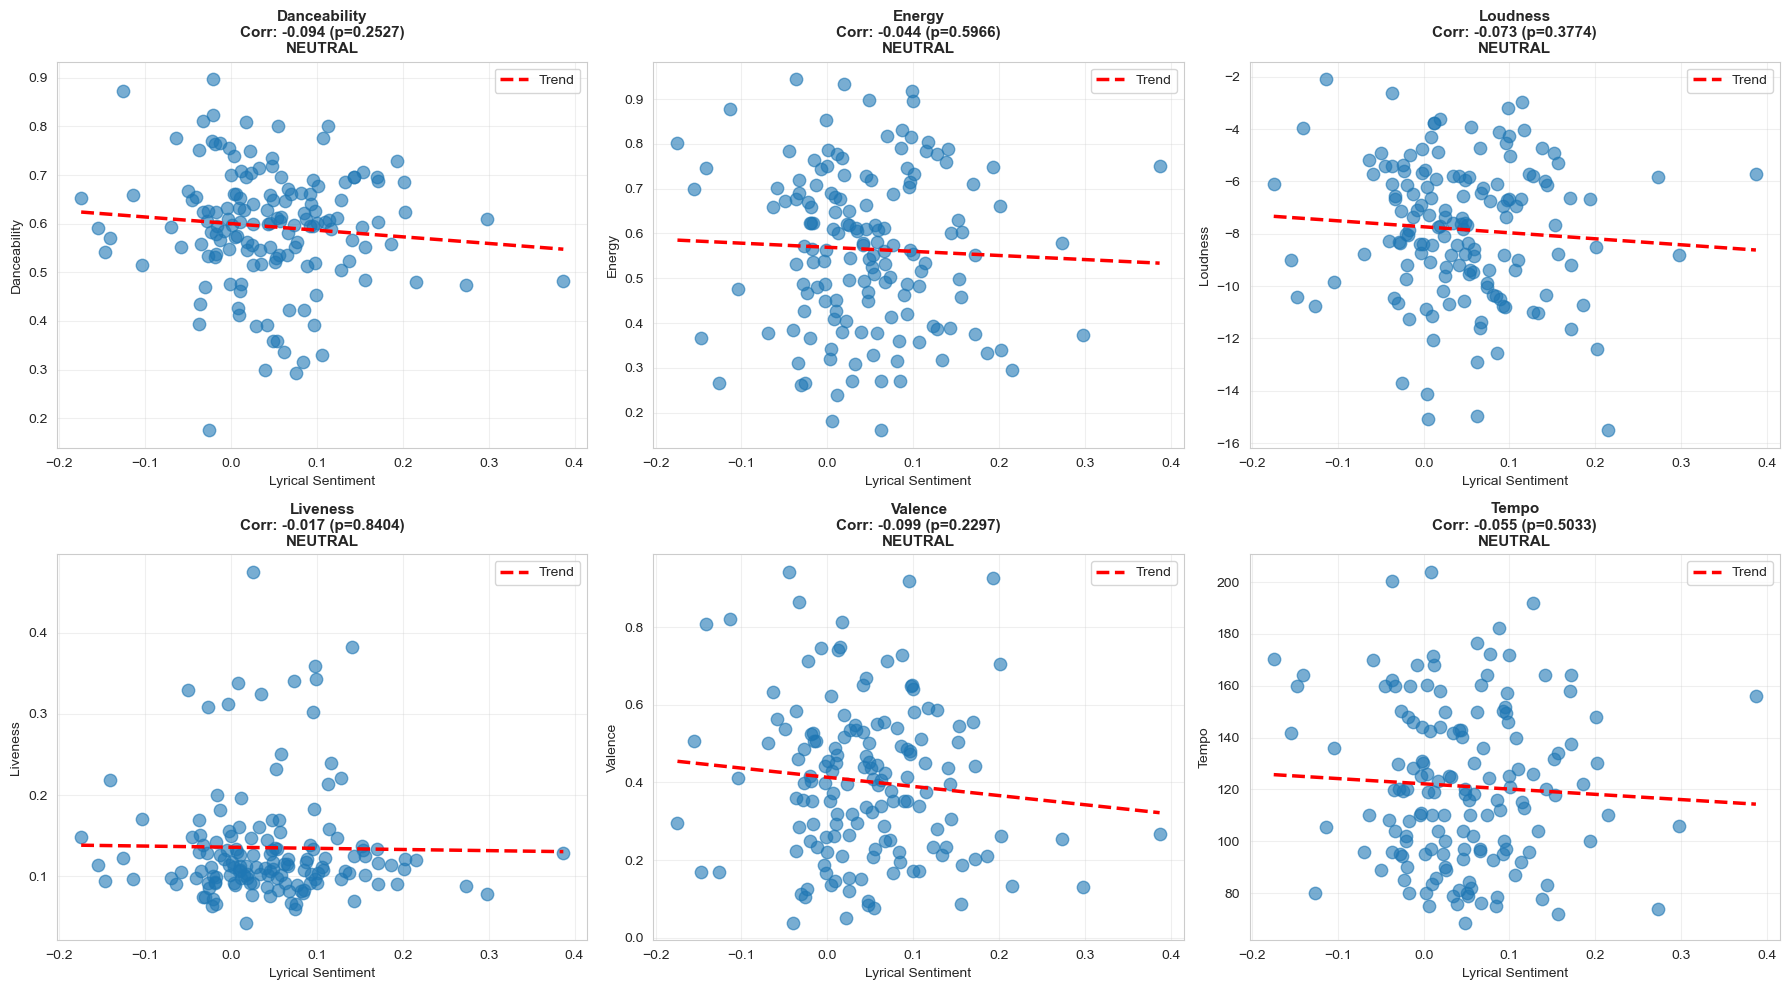

In [17]:
# ===== 6. INDIVIDUAL AUDIO FEATURE ANALYSIS =====
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(audio_features):
    axes[idx].scatter(song_level['sentiment_score'], song_level[feature], alpha=0.6, s=80)
    
    # Add trend line
    z = np.polyfit(song_level['sentiment_score'], song_level[feature], 1)
    p = np.poly1d(z)
    x_line = np.linspace(song_level['sentiment_score'].min(), song_level['sentiment_score'].max(), 100)
    axes[idx].plot(x_line, p(x_line), "r--", linewidth=2.5, label='Trend')
    
    # Calculate correlation
    corr, p_val = pearsonr(song_level['sentiment_score'], song_level[feature])
    
    # Interpret correlation for irony
    irony_text = "← MORE IRONIC" if corr < -0.1 else "← ALIGNED" if corr > 0.1 else "NEUTRAL"
    
    axes[idx].set_title(f'{feature.capitalize()}\nCorr: {corr:.3f} (p={p_val:.4f})\n{irony_text}', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Lyrical Sentiment', fontsize=10)
    axes[idx].set_ylabel(feature.capitalize(), fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

plt.tight_layout()
plt.savefig('04_feature_analysis.png', dpi=300, bbox_inches='tight')
plt.show()



In [18]:
# ===== 7. CORRELATION INTERPRETATION =====
print("\n=== CORRELATION ANALYSIS (Irony Detection) ===")
print("Negative correlation = Ironic (sad lyrics, upbeat music)")
print("Positive correlation = Aligned (sentiment matches music)\n")

for feature in audio_features:
    corr, p_val = pearsonr(song_level['sentiment_score'], song_level[feature])
    significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    irony_indicator = "← IRONIC" if corr < -0.15 else "← ALIGNED" if corr > 0.15 else ""
    print(f"{feature:12} | r={corr:6.3f} | p={p_val:.4f} {significance:3} {irony_indicator}")





=== CORRELATION ANALYSIS (Irony Detection) ===
Negative correlation = Ironic (sad lyrics, upbeat music)
Positive correlation = Aligned (sentiment matches music)

danceability | r=-0.094 | p=0.2527 ns  
energy       | r=-0.044 | p=0.5966 ns  
loudness     | r=-0.073 | p=0.3774 ns  
liveness     | r=-0.017 | p=0.8404 ns  
valence      | r=-0.099 | p=0.2297 ns  
tempo        | r=-0.055 | p=0.5033 ns  


In [19]:
# ===== 8. TOP IRONIC SONGS =====
print("\n" + "="*80)
print("MOST IRONIC SONGS: HAPPY MUSIC + SAD LYRICS")
print("="*80)
most_ironic = song_level.nlargest(10, 'irony_score')[['track_name_formatted', 'sentiment_score', 
                                                        'valence_energy_avg', 'irony_score', 'year']]
for idx, (_, row) in enumerate(most_ironic.iterrows(), 1):
    print(f"{idx:2}. {row['track_name_formatted']:30} | Sentiment: {row['sentiment_score']:6.3f} | "
          f"Musical: {row['valence_energy_avg']:6.3f} | Irony: {row['irony_score']:6.3f} ({row['year']})")

print("\n" + "="*80)
print("MOST ALIGNED SONGS: MUSIC AND LYRICS MATCH")
print("="*80)
least_ironic = song_level.nsmallest(10, 'irony_score')[['track_name_formatted', 'sentiment_score', 
                                                         'valence_energy_avg', 'irony_score', 'year']]
for idx, (_, row) in enumerate(least_ironic.iterrows(), 1):
    print(f"{idx:2}. {row['track_name_formatted']:30} | Sentiment: {row['sentiment_score']:6.3f} | "
          f"Musical: {row['valence_energy_avg']:6.3f} | Irony: {row['irony_score']:6.3f} ({row['year']})")




MOST IRONIC SONGS: HAPPY MUSIC + SAD LYRICS
 1. Picture To Burn                | Sentiment: -0.114 | Musical:  0.849 | Irony:  0.963 (2006)
 2. Mean                           | Sentiment: -0.141 | Musical:  0.778 | Irony:  0.918 (2010)
 3. Shake It Off                   | Sentiment: -0.045 | Musical:  0.864 | Irony:  0.909 (2014)
 4. Paper Rings                    | Sentiment: -0.033 | Musical:  0.792 | Irony:  0.825 (2019)
 5. I Can See You                  | Sentiment:  0.017 | Musical:  0.790 | Irony:  0.773 (2023)
 6. mad woman                      | Sentiment: -0.155 | Musical:  0.603 | Irony:  0.757 (2020)
 7. Babe                           | Sentiment: -0.008 | Musical:  0.744 | Irony:  0.752 (2021)
 8. Bad Blood                      | Sentiment: -0.174 | Musical:  0.548 | Irony:  0.723 (2014)
 9. closure                        | Sentiment:  0.095 | Musical:  0.812 | Irony:  0.717 (2020)
10. You Need To Calm Down          | Sentiment: -0.023 | Musical:  0.693 | Irony:  0.715 (2


=== IRONY BY ALBUM ===
                              irony_score              sentiment_score  \
                                     mean    std count            mean   
album_name                                                               
1989                                0.575  0.226    10          -0.002   
Speak Now (Taylor's Version)        0.543  0.136     6           0.040   
Taylor Swift                        0.515  0.264     9           0.079   
Lover                               0.513  0.169    15           0.024   
Red                                 0.498  0.179    12           0.087   
Speak Now                           0.481  0.212    12           0.030   
Red (Taylor's Version)              0.470  0.176     8           0.082   
Fearless (Taylor's Version)         0.420  0.240     8           0.057   
evermore                            0.407  0.171    14           0.053   
reputation                          0.397  0.134    10           0.058   
folklore      

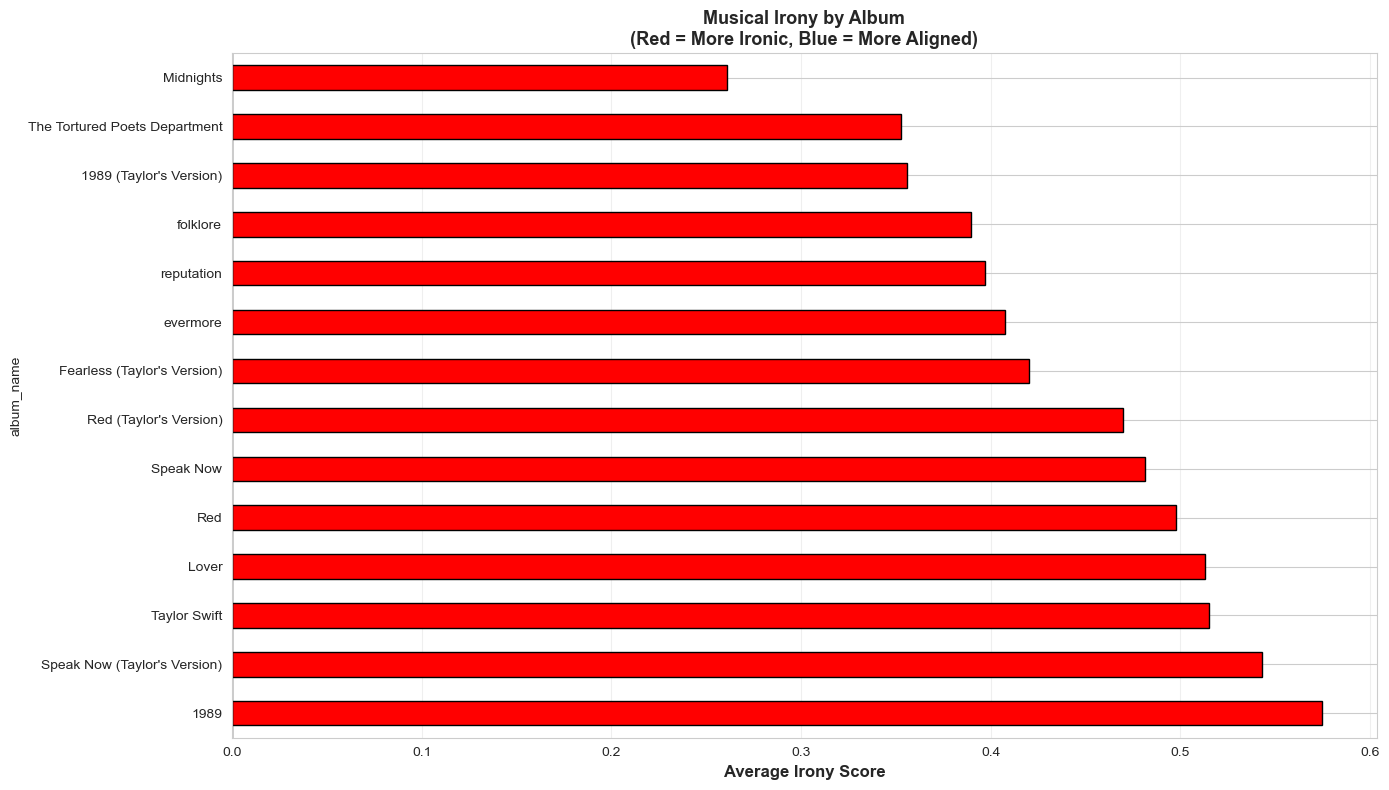

In [20]:
# ===== 9. IRONY BY ALBUM AND YEAR =====
print("\n=== IRONY BY ALBUM ===")
album_irony = song_level.groupby('album_name').agg({
    'irony_score': ['mean', 'std', 'count'],
    'sentiment_score': 'mean',
    'valence_energy_avg': 'mean'
}).round(3)
print(album_irony.sort_values(('irony_score', 'mean'), ascending=False))

fig, ax = plt.subplots(figsize=(14, 8))
album_summary = song_level.groupby('album_name')['irony_score'].mean().sort_values(ascending=False)
colors_bars = ['red' if x > 0.1 else 'gold' if x > -0.1 else 'blue' for x in album_summary.values]
album_summary.plot(kind='barh', ax=ax, color=colors_bars, edgecolor='black')
ax.set_xlabel('Average Irony Score', fontsize=12, fontweight='bold')
ax.set_title('Musical Irony by Album\n(Red = More Ironic, Blue = More Aligned)', 
            fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('05_irony_by_album.png', dpi=300, bbox_inches='tight')
plt.show()


In [21]:
# ===== 10. KEY FINDINGS SUMMARY =====
print("\n" + "="*80)
print("KEY FINDINGS: IS TAYLOR SWIFT MUSICALLY IRONIC?")
print("="*80)

overall_irony = song_level['irony_score'].mean()
print(f"\nOverall Average Irony Score: {overall_irony:.3f}")

if overall_irony > 0.1:
    print("YES - Taylor Swift tends to write SAD LYRICS over UPBEAT music")
    print("This suggests deliberate musical irony in her production choices")
elif overall_irony < -0.1:
    print("NO - Taylor Swift tends to write HAPPY LYRICS over CALM music")
    print("Her music generally aligns with her lyrical sentiment")
else:
    print("NEUTRAL - Taylor Swift's music sentiment is well-aligned with her lyrics")
    print("She doesn't show a strong pattern of musical irony")

# Irony percentage
ironic_songs = (song_level['irony_score'] > 0.2).sum()
irony_pct = (ironic_songs / len(song_level)) * 100
print(f"\n{ironic_songs} songs ({irony_pct:.1f}%) are clearly ironic (happy music + sad lyrics)")
print(f"Average irony magnitude: {abs(song_level['irony_score']).mean():.3f}")

print("\n" + "="*80)

# Save aggregated data
song_level.to_csv('taylor_swift_songs_with_irony.csv', index=False)
print("\n Song-level data saved to: taylor_swift_songs_with_irony.csv")
print("Visualizations saved as: 01_sentiment_distribution.png, etc.")


KEY FINDINGS: IS TAYLOR SWIFT MUSICALLY IRONIC?

Overall Average Irony Score: 0.439
YES - Taylor Swift tends to write SAD LYRICS over UPBEAT music
This suggests deliberate musical irony in her production choices

137 songs (91.9%) are clearly ironic (happy music + sad lyrics)
Average irony magnitude: 0.439


 Song-level data saved to: taylor_swift_songs_with_irony.csv
Visualizations saved as: 01_sentiment_distribution.png, etc.
